In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [2]:
# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Define class labels
class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print("Dataset loaded successfully")

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Dataset loaded successfully


In [3]:
# Build a Convolutional Neural Network (CNN)

model = models.Sequential()

# First convolution + pooling layer
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# Second convolution + pooling layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Third convolution layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten feature maps into 1D vector
model.add(layers.Flatten())

# Fully connected layer
model.add(layers.Dense(128, activation='relu'))

# Output layer (10 classes)
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Compile the model (define optimizer, loss, and metrics)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
# Train the CNN model

print("Training started...")

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Training started...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 47ms/step - accuracy: 0.4560 - loss: 1.4907 - val_accuracy: 0.5675 - val_loss: 1.2090
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 46ms/step - accuracy: 0.6089 - loss: 1.1040 - val_accuracy: 0.6271 - val_loss: 1.0417
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.6667 - loss: 0.9396 - val_accuracy: 0.6361 - val_loss: 1.0308
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7061 - loss: 0.8325 - val_accuracy: 0.6925 - val_loss: 0.8868
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 49ms/step - accuracy: 0.7362 - loss: 0.7478 - val_accuracy: 0.6993 - val_loss: 0.8905
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.7577 - loss: 0.6823 - val_accuracy: 0.7013 - val_loss: 0.8692
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.7790 - loss: 0.6246 - val_accuracy: 0.7101 - val_loss: 0.8577
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step 

In [6]:
# Evaluate model performance on test data

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7093 - loss: 0.9642
Test Accuracy: 0.7092999815940857


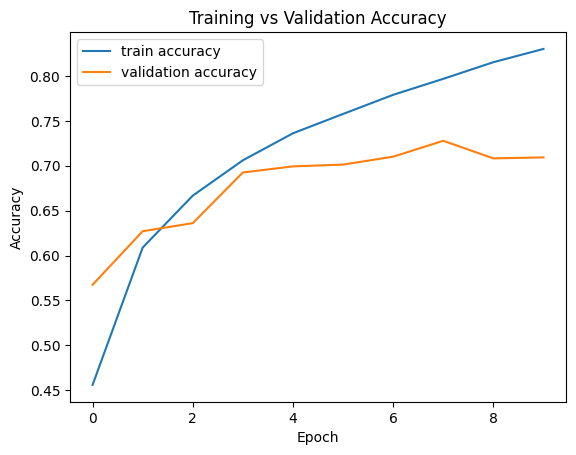

In [7]:
# Plot training vs validation accuracy

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()